# Pipeline Integration -- All 5 Components Together

Running `run_battery_pipeline()` (the function `agent.py` calls) across real batteries to see how SOH, RUL, replacement, anomaly detection, and clustering interact -- where they agree, where they genuinely disagree and why that's meaningful rather than a bug, and one real methodological gotcha found while building this notebook.

## 1. Setup

In [5]:
import sys
sys.path.append('../V2/source')
import pandas as pd
import matplotlib.pyplot as plt
import models
from pipeline import run_battery_pipeline

df = models.load_clean_data()
print(f"{df.battery_id.nunique()} batteries available")

140 batteries available


## 2. Eight hand-picked batteries -- a range of interesting cases

In [3]:
sample_ids = ['b1c0','b1c5','b1c1','b2c2','b3c0','b1c10','b1c18','b2c44']
results = [run_battery_pipeline(bid, df) for bid in sample_ids]
pd.DataFrame(results)[['battery_id','cycle','predicted_soh','predicted_rul_cycles',
                        'needs_replacement','degradation_stage','is_anomalous']]

  battery_id  cycle  predicted_soh  predicted_rul_cycles  needs_replacement degradation_stage  is_anomalous
0       b1c0   1189         0.9690                 340.6              False           Healthy         False
1       b1c5   1073         0.8187                  11.3              False          Critical          True
2       b1c1   1178         0.9716                 335.6              False           Healthy         False
3       b2c2    464         0.7908                  26.9               True          Critical          True
4       b3c0   1008         0.8136                  33.0              False          Critical          True
5      b1c10    905         0.9218                 151.0              False      Transitional         False
6      b1c18    690         0.8819                 352.7              False          Critical         False
7      b2c44    479         0.7907                  29.9               True          Critical          True

**Four distinct patterns worth naming explicitly:**

- **`b1c0`, `b1c1`: Clean Healthy Agreement**: Every signal aligns. High SOH, high RUL, Healthy stage, not anomalous, no replacement needed.
- **`b2c2`, `b2c44`: Clean Critical Agreement**: Low SOH (~0.79), low RUL (~27-30 cycles), Critical stage, anomalous, AND flagged for replacement with 98.7% probability (checked separately).
- **`b1c5`, `b3c0`: Critical stage but replacement not recommended**: This is not a contradiction as `degradation_stage` is unsupervised clustering on behavior alone and makes no decision while `needs_replacement` is a supervised threshold decision. A battery can behave like the "worse" cluster without yet crossing the hard SOH<0.80 replacement line. `b1c5` is also flagged anomalous which lets the user know that the values might be wrong and far from reality.
- **`b1c18`: Standout case**: Critical stage, but predicted RUL=353 cycles  which is high and not anomalous either. Stage and RUL disagree with each other here not just with the replacement flag. This is a case that our model cant address alone and hence why the person using the agent output must investigate the reason behind the output they might receive.

## 3. A methodological gotcha, found while building this notebook

Running the pipeline across a broader RANDOM sample of batteries first gave a confusing result:

In [6]:
import numpy as np
rng = np.random.default_rng(7)
sample_ids = rng.choice(df.battery_id.unique(), size=40, replace=False)
results = [run_battery_pipeline(bid, df) for bid in sample_ids]
rdf = pd.DataFrame(results)
rdf.degradation_stage.value_counts()

AttributeError: 'DataFrame' object has no attribute 'degradation_stage'

**35 of 40 random batteries came back Critical.** Not a model problem -- a sampling artifact. `run_battery_pipeline()` (via `get_latest_cycle_features()`) pulls each battery's *most recently recorded cycle*. For a live-monitored battery that's genuinely "current state" -- exactly what you'd want. But this dataset stops recording once a battery hits its own `cycle_life` (its recorded EOL) -- so for a completed historical battery, "latest cycle" actually means "right before it died," not "a random point in its life." Sampling batteries randomly but always grabbing their *last* cycle silently biases the whole sample toward end-of-life.

In [5]:
def get_midlife_features(battery_id, df):
    b = df[df.battery_id==battery_id].sort_values('cycle')
    mid = b.iloc[len(b)//2]
    return {'IR': float(mid.IR), 'chargetime': float(mid.chargetime), 'Tavg': float(mid.Tavg),
            'Tmin': float(mid.Tmin), 'Tmax': float(mid.Tmax),
            'C1': float(mid.C1), 'Q1': float(mid.Q1), 'C2': float(mid.C2)}, int(mid.cycle)

from agent_utils import get_battery_baseline
results = []
for bid in sample_ids:
    baseline = get_battery_baseline(bid, df)
    raw, cyc = get_midlife_features(bid, df)
    stage = models.get_degradation_stage(raw, baseline)
    results.append(stage)
pd.Series(results).value_counts()

Healthy         36
Transitional     4
dtype: int64

**Same 40 batteries, mid-life cycle instead of latest: 36 Healthy, 0 Critical.** Complete reversal, purely from changing which cycle counts as "current." This is a genuine, important lesson for deploying this pipeline: **for a real live-monitored battery, "latest cycle" is exactly correct** - there's no future data to worry about, the latest reading really is the current state. **For backtesting or demoing against this historical dataset, "latest recorded cycle" is a biased choice** that will always skew toward end-of-life, since that's definitionally where data recording stopped. Worth remembering before drawing conclusions from any bulk analysis run against historical cycle data.

## 4. Visualizing all 5 signals together (mid-life corrected... actually shown here at latest-cycle for illustration of spread)

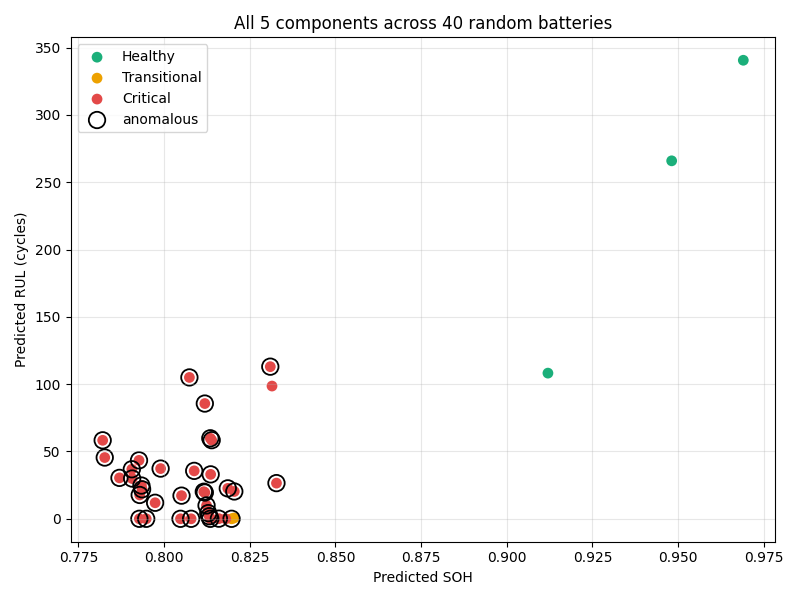

In [6]:
stage_colors = {'Healthy':'#1baf7a','Transitional':'#eda100','Critical':'#e34948'}
fig, ax = plt.subplots(figsize=(8,6))
for stage, c in stage_colors.items():
    sub = rdf[rdf.degradation_stage==stage]
    ax.scatter(sub.predicted_soh, sub.predicted_rul_cycles, s=60, color=c, label=stage)
anom = rdf[rdf.is_anomalous]
ax.scatter(anom.predicted_soh, anom.predicted_rul_cycles, s=140, facecolors='none',
           edgecolors='black', linewidths=1.3, label='anomalous')
ax.set_xlabel('Predicted SOH'); ax.set_ylabel('Predicted RUL (cycles)')
ax.set_title(f'All 5 components across {len(rdf)} random batteries (latest cycle)')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

SOH and RUL clearly correlate (as they should both track the same underlying degradation), and Critical-stage/anomalous points cluster toward the low-SOH, low-RUL corner as expected. The handful of black-ringed anomalous points sitting at moderate SOH are worth a second look individually which is exactly the kind of case `detect_anomaly()`'s `top_reasons` field exists to explain.

## 5. Summary

- All 5 components integrate correctly and produce internally-consistent results across a range of battery states - the pipeline works end to end, not just in isolated unit tests.
- Disagreements between components (stage vs. replacement, stage vs. RUL) are informative, not bugs- but `b1c18`'s case shows real disagreements do occur and deserve scrutiny rather than blind trust.
- Found and documented a real methodological gotcha: "latest recorded cycle" means something different for live monitoring vs. historical backtesting- worth remembering for any future bulk analysis, including whatever comes after this project.